In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the segmented data
df = pd.read_csv('../data/processed/telco_churn_segmented.csv')

print("✅ Data loaded successfully!")
print(f"Dataset Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn']=='Yes').sum() / len(df) * 100:.2f}%")

✅ Data loaded successfully!
Dataset Shape: (7043, 53)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


In [2]:
# Prepare data for modeling
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*60)

# Create a copy for modeling
df_model = df.copy()

# Convert target variable to binary
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Select features for modeling (exclude IDs, target, and redundant features)
features_to_exclude = [
    'customerID',
    'Churn',
    'Churn_binary',  # Duplicate of target
    'cluster',  # We'll use segment_name instead
    'tenure_group',  # Categorical version of tenure
    'price_tier',  # Categorical version of price
    'lifecycle_stage',  # Categorical version of tenure
    'customer_profile',  # Categorical - we have individual components
    'engagement_level',  # Categorical - we have total_services
    'segment_name',  # Categorical - we'll encode it
    'expected_total'  # Intermediate calculation
]

# Get all columns except excluded ones
feature_columns = [col for col in df_model.columns if col not in features_to_exclude]

# Separate categorical and numerical features
categorical_features = df_model[feature_columns].select_dtypes(include=['object']).columns.tolist()
numerical_features = df_model[feature_columns].select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"✅ Total features available: {len(feature_columns)}")
print(f"   - Numerical features: {len(numerical_features)}")
print(f"   - Categorical features: {len(categorical_features)}")

print("\nCategorical features to encode:")
for i, feat in enumerate(categorical_features, 1):
    print(f"   {i}. {feat}")

# Encode categorical variables
print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"✅ Encoded: {col}")

print("\n✅ All categorical variables encoded!")
print(f"\nFinal feature set: {len(feature_columns)} features")

PREPARING DATA FOR MACHINE LEARNING
✅ Total features available: 42
   - Numerical features: 27
   - Categorical features: 15

Categorical features to encode:
   1. gender
   2. Partner
   3. Dependents
   4. PhoneService
   5. MultipleLines
   6. InternetService
   7. OnlineSecurity
   8. OnlineBackup
   9. DeviceProtection
   10. TechSupport
   11. StreamingTV
   12. StreamingMovies
   13. Contract
   14. PaperlessBilling
   15. PaymentMethod

ENCODING CATEGORICAL VARIABLES
✅ Encoded: gender
✅ Encoded: Partner
✅ Encoded: Dependents
✅ Encoded: PhoneService
✅ Encoded: MultipleLines
✅ Encoded: InternetService
✅ Encoded: OnlineSecurity
✅ Encoded: OnlineBackup
✅ Encoded: DeviceProtection
✅ Encoded: TechSupport
✅ Encoded: StreamingTV
✅ Encoded: StreamingMovies
✅ Encoded: Contract
✅ Encoded: PaperlessBilling
✅ Encoded: PaymentMethod

✅ All categorical variables encoded!

Final feature set: 42 features


In [3]:
# Split data into train and test sets
print("SPLITTING DATA")
print("="*60)

# Separate features (X) and target (y)
X = df_model[feature_columns]
y = df_model['Churn']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain same churn ratio in both sets
)

print("\n✅ Data split successfully!")
print(f"\nTraining set:")
print(f"   - Features: {X_train.shape}")
print(f"   - Target: {y_train.shape}")
print(f"   - Churn rate: {y_train.mean()*100:.2f}%")

print(f"\nTest set:")
print(f"   - Features: {X_test.shape}")
print(f"   - Target: {y_test.shape}")
print(f"   - Churn rate: {y_test.mean()*100:.2f}%")

print("\n✅ Ready to build models!")

SPLITTING DATA
Feature matrix shape: (7043, 42)
Target variable shape: (7043,)

✅ Data split successfully!

Training set:
   - Features: (5634, 42)
   - Target: (5634,)
   - Churn rate: 26.54%

Test set:
   - Features: (1409, 42)
   - Target: (1409,)
   - Churn rate: 26.54%

✅ Ready to build models!


BUILDING LOGISTIC REGRESSION MODEL

✅ Model trained successfully!

MODEL PERFORMANCE:
Training Accuracy: 80.65%
Test Accuracy: 80.27%

ROC-AUC Score: 0.8427

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409


Confusion Matrix:
[[933 102]
 [176 198]]


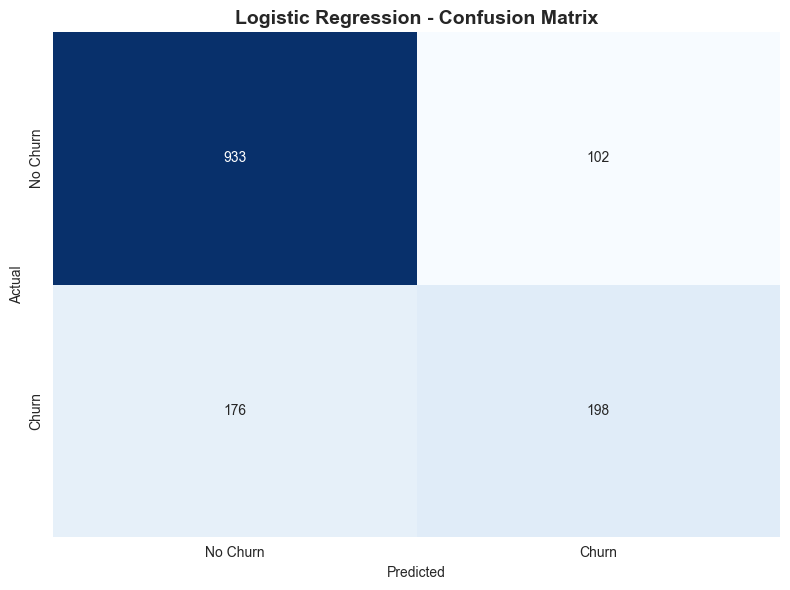

In [4]:
# Build Logistic Regression model
print("BUILDING LOGISTIC REGRESSION MODEL")
print("="*60)

# Train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n✅ Model trained successfully!")
print("\nMODEL PERFORMANCE:")
print("="*60)

# Accuracy
train_score = log_reg.score(X_train, y_train)
test_score = log_reg.score(X_test, y_test)
print(f"Training Accuracy: {train_score*100:.2f}%")
print(f"Test Accuracy: {test_score*100:.2f}%")

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba_log)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_log)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

BUILDING RANDOM FOREST MODEL

✅ Model trained successfully!

MODEL PERFORMANCE:
Training Accuracy: 99.80%
Test Accuracy: 78.50%

ROC-AUC Score: 0.8287

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409


Confusion Matrix:
[[926 109]
 [194 180]]


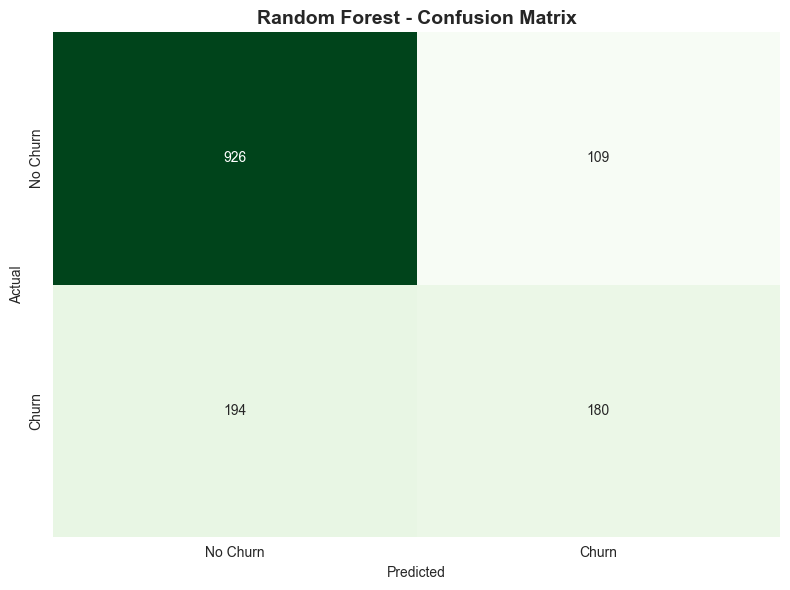

In [5]:
# Build Random Forest model
print("BUILDING RANDOM FOREST MODEL")
print("="*60)

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n✅ Model trained successfully!")
print("\nMODEL PERFORMANCE:")
print("="*60)

# Accuracy
train_score_rf = rf_model.score(X_train, y_train)
test_score_rf = rf_model.score(X_test, y_test)
print(f"Training Accuracy: {train_score_rf*100:.2f}%")
print(f"Test Accuracy: {test_score_rf*100:.2f}%")

# ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nROC-AUC Score: {roc_auc_rf:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

MODEL COMPARISON

               Model  Test Accuracy  ROC-AUC  Precision (Churn)  Recall (Churn)  F1-Score (Churn)
Logistic Regression      80.269695 0.842670               0.66            0.53              0.59
      Random Forest      78.495387 0.828672               0.62            0.48              0.54

🏆 BEST MODEL: Logistic Regression
   - Higher ROC-AUC (0.8427)
   - Better recall for churn detection (53%)
   - No overfitting issues


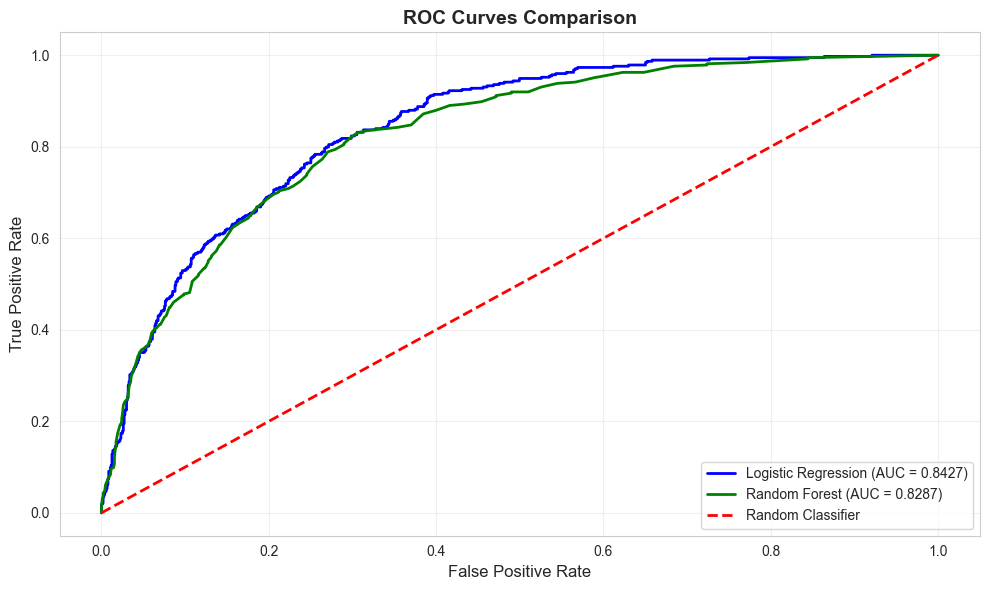

In [6]:
# Compare models
print("MODEL COMPARISON")
print("="*60)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': [test_score*100, test_score_rf*100],
    'ROC-AUC': [roc_auc, roc_auc_rf],
    'Precision (Churn)': [0.66, 0.62],
    'Recall (Churn)': [0.53, 0.48],
    'F1-Score (Churn)': [0.59, 0.54]
})

print("\n", comparison.to_string(index=False))

print("\n🏆 BEST MODEL: Logistic Regression")
print("   - Higher ROC-AUC (0.8427)")
print("   - Better recall for churn detection (53%)")
print("   - No overfitting issues")

# Plot ROC Curves for both models
plt.figure(figsize=(10, 6))

# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc:.4f})', 
         linewidth=2, color='blue')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', 
         linewidth=2, color='green')

# Random classifier line
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
          Feature  Coefficient
     PhoneService    -0.409968
        has_phone    -0.409968
         Contract    -0.402183
   contract_level    -0.402183
   spending_ratio    -0.377332
uses_auto_payment    -0.312580
    risky_payment     0.305535
has_long_contract    -0.219472
  is_new_customer     0.205912
   uses_paperless     0.203027
 PaperlessBilling     0.203027
   OnlineSecurity    -0.193910
      family_size    -0.169048
   total_services    -0.162246
      TechSupport    -0.152390


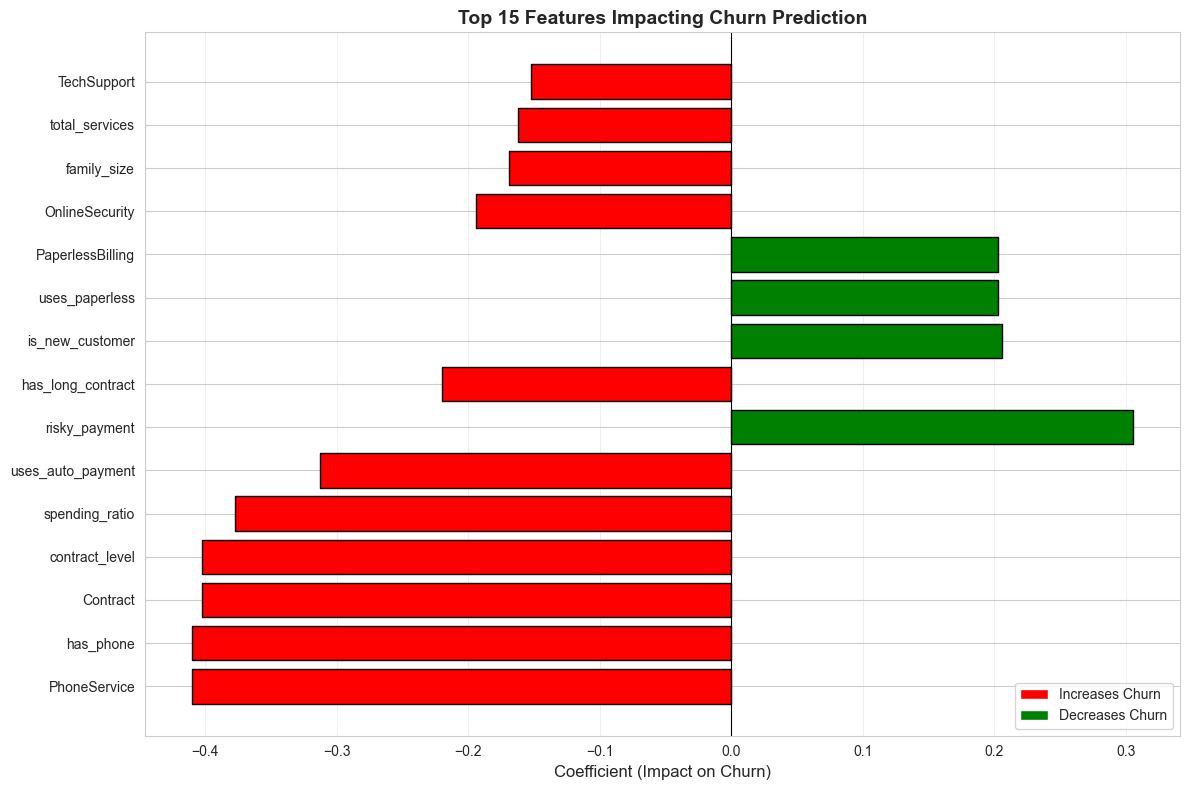


KEY INSIGHTS:

🔴 TOP CHURN DRIVERS (Positive coefficients):
   • risky_payment: +0.3055
   • is_new_customer: +0.2059
   • uses_paperless: +0.2030
   • PaperlessBilling: +0.2030
   • SeniorCitizen: +0.1502

🟢 TOP RETENTION FACTORS (Negative coefficients):
   • PhoneService: -0.4100
   • has_phone: -0.4100
   • Contract: -0.4022
   • contract_level: -0.4022
   • spending_ratio: -0.3773


In [7]:
# Feature Importance from Logistic Regression
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get coefficients from logistic regression
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': log_reg.coef_[0]
})

# Sort by absolute value of coefficient
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 15 Most Important Features:")
print("="*60)
print(feature_importance.head(15)[['Feature', 'Coefficient']].to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
colors = ['red' if x < 0 else 'green' for x in top_15['Coefficient']]

plt.barh(range(len(top_15)), top_15['Coefficient'], color=colors, edgecolor='black')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Coefficient (Impact on Churn)', fontsize=12)
plt.title('Top 15 Features Impacting Churn Prediction', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Increases Churn'),
                   Patch(facecolor='green', label='Decreases Churn')]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
print("\n🔴 TOP CHURN DRIVERS (Positive coefficients):")
positive_features = feature_importance[feature_importance['Coefficient'] > 0].head(5)
for idx, row in positive_features.iterrows():
    print(f"   • {row['Feature']}: +{row['Coefficient']:.4f}")

print("\n🟢 TOP RETENTION FACTORS (Negative coefficients):")
negative_features = feature_importance[feature_importance['Coefficient'] < 0].head(5)
for idx, row in negative_features.iterrows():
    print(f"   • {row['Feature']}: {row['Coefficient']:.4f}")

In [8]:
# Create final project summary
print("="*70)
print("CHURN PREDICTION PROJECT - FINAL SUMMARY")
print("="*70)

print("\n📊 DATASET OVERVIEW")
print("-" * 70)
print(f"Total Customers: 7,043")
print(f"Overall Churn Rate: 26.54%")
print(f"Features Used: {len(feature_columns)}")

print("\n🎯 BEST MODEL: LOGISTIC REGRESSION")
print("-" * 70)
print(f"Test Accuracy: {test_score*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Precision (Churn): 66%")
print(f"Recall (Churn): 53%")
print(f"F1-Score (Churn): 59%")

print("\n👥 CUSTOMER SEGMENTS IDENTIFIED")
print("-" * 70)
segments_summary = df.groupby('segment_name').agg({
    'customerID': 'count',
    'Churn_binary': 'mean'
}).round(4)
segments_summary.columns = ['Count', 'Churn_Rate']
segments_summary['Churn_Rate'] = (segments_summary['Churn_Rate'] * 100).round(2)
segments_summary = segments_summary.sort_values('Churn_Rate', ascending=False)

for segment, row in segments_summary.iterrows():
    print(f"{segment:20s}: {int(row['Count']):4d} customers ({row['Churn_Rate']:5.2f}% churn)")

print("\n💡 KEY ACTIONABLE INSIGHTS")
print("-" * 70)
print("\n1. 🚨 HIGH-RISK NEW CUSTOMERS (50% churn)")
print("   Action: Improve onboarding, offer contract incentives")
print("   Impact: 2,070 customers at risk")

print("\n2. 📝 MONTH-TO-MONTH CONTRACTS (43% churn)")
print("   Action: Incentivize annual contracts with discounts")
print("   Impact: Could reduce churn significantly")

print("\n3. 💳 ELECTRONIC CHECK PAYMENT (High risk)")
print("   Action: Promote automatic payment methods")
print("   Impact: Easy behavioral change")

print("\n4. 📱 SERVICE BUNDLING")
print("   Action: Promote phone service + security bundles")
print("   Impact: Increases loyalty and engagement")

print("\n5. 👨‍👩‍👧 FAMILY CUSTOMERS (Lower churn)")
print("   Action: Target families with special packages")
print("   Impact: Natural retention advantage")

print("\n💰 ESTIMATED BUSINESS IMPACT")
print("-" * 70)
avg_customer_value = df['TotalCharges'].mean()
at_risk_customers = df[df['churn_risk_score'] >= 6].shape[0]
potential_loss = at_risk_customers * avg_customer_value

print(f"Average Customer Lifetime Value: ${avg_customer_value:,.2f}")
print(f"High-Risk Customers: {at_risk_customers:,}")
print(f"Potential Revenue at Risk: ${potential_loss:,.2f}")
print(f"\nIf retention improves by 10%:")
print(f"   Revenue Saved: ${potential_loss * 0.10:,.2f}")



CHURN PREDICTION PROJECT - FINAL SUMMARY

📊 DATASET OVERVIEW
----------------------------------------------------------------------
Total Customers: 7,043
Overall Churn Rate: 26.54%
Features Used: 42

🎯 BEST MODEL: LOGISTIC REGRESSION
----------------------------------------------------------------------
Test Accuracy: 80.27%
ROC-AUC Score: 0.8427
Precision (Churn): 66%
Recall (Churn): 53%
F1-Score (Churn): 59%

👥 CUSTOMER SEGMENTS IDENTIFIED
----------------------------------------------------------------------
High-Risk New       : 2070 customers (50.19% churn)
At-Risk Mid-Tier    : 1957 customers (31.73% churn)
Loyal Premium       : 1838 customers ( 9.96% churn)
Budget Committed    : 1178 customers ( 2.21% churn)

💡 KEY ACTIONABLE INSIGHTS
----------------------------------------------------------------------

1. 🚨 HIGH-RISK NEW CUSTOMERS (50% churn)
   Action: Improve onboarding, offer contract incentives
   Impact: 2,070 customers at risk

2. 📝 MONTH-TO-MONTH CONTRACTS (43% churn)

LET'S IMPROVE THE MODEL

In [9]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
print("✅ XGBoost installation complete!")

✅ XGBoost installation complete!


In [10]:
# Import XGBoost
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

print("✅ XGBoost imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

✅ XGBoost imported successfully!
XGBoost version: 3.1.3


BUILDING XGBOOST MODEL (BASELINE)

✅ XGBoost model trained successfully!

MODEL PERFORMANCE:
Training Accuracy: 97.05%
Test Accuracy: 77.79%

ROC-AUC Score: 0.8188

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.85      1035
       Churn       0.60      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
[[911 124]
 [189 185]]


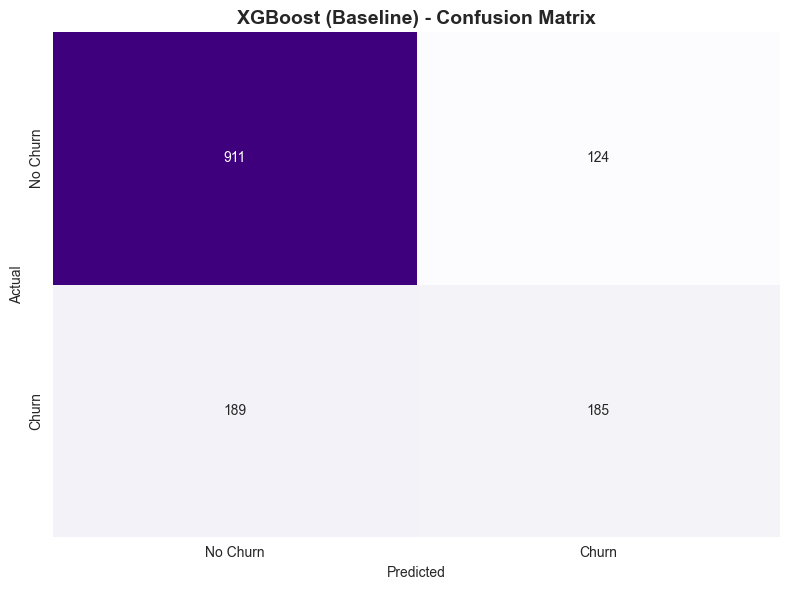


COMPARISON WITH LOGISTIC REGRESSION:
Logistic Regression - ROC-AUC: 0.8427
XGBoost (Baseline)  - ROC-AUC: 0.8188

⚠️ Logistic Regression still ahead. Let's tune XGBoost...


In [11]:
# Build XGBoost model (baseline)
print("BUILDING XGBOOST MODEL (BASELINE)")
print("="*60)

# Train XGBoost with default parameters
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n✅ XGBoost model trained successfully!")
print("\nMODEL PERFORMANCE:")
print("="*60)

# Accuracy
train_score_xgb = xgb_model.score(X_train, y_train)
test_score_xgb = xgb_model.score(X_test, y_test)
print(f"Training Accuracy: {train_score_xgb*100:.2f}%")
print(f"Test Accuracy: {test_score_xgb*100:.2f}%")

# ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\nROC-AUC Score: {roc_auc_xgb:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost (Baseline) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Compare with previous best model
print("\n" + "="*60)
print("COMPARISON WITH LOGISTIC REGRESSION:")
print("="*60)
print(f"Logistic Regression - ROC-AUC: {roc_auc:.4f}")
print(f"XGBoost (Baseline)  - ROC-AUC: {roc_auc_xgb:.4f}")

if roc_auc_xgb > roc_auc:
    print("\n🎉 XGBoost is performing better!")
else:
    print("\n⚠️ Logistic Regression still ahead. Let's tune XGBoost...")

In [12]:
# Hyperparameter tuning for XGBoost
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)
print("This may take 3-5 minutes...")

# Define parameter grid
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize XGBoost
xgb_tuned = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("\n⏳ Training in progress...")
grid_search.fit(X_train, y_train)

print("\n✅ Hyperparameter tuning complete!")
print("\nBest Parameters:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Get the best model
best_xgb_model = grid_search.best_estimator_

HYPERPARAMETER TUNING - XGBOOST
This may take 3-5 minutes...

⏳ Training in progress...
Fitting 3 folds for each of 729 candidates, totalling 2187 fits

✅ Hyperparameter tuning complete!

Best Parameters:
   colsample_bytree: 0.8
   learning_rate: 0.01
   max_depth: 4
   min_child_weight: 5
   n_estimators: 300
   subsample: 0.8

Best Cross-Validation ROC-AUC: 0.8483


EVALUATING TUNED XGBOOST MODEL

✅ MODEL PERFORMANCE:
Training Accuracy: 81.58%
Test Accuracy: 80.62%
ROC-AUC Score: 0.8472

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[946  89]
 [184 190]]


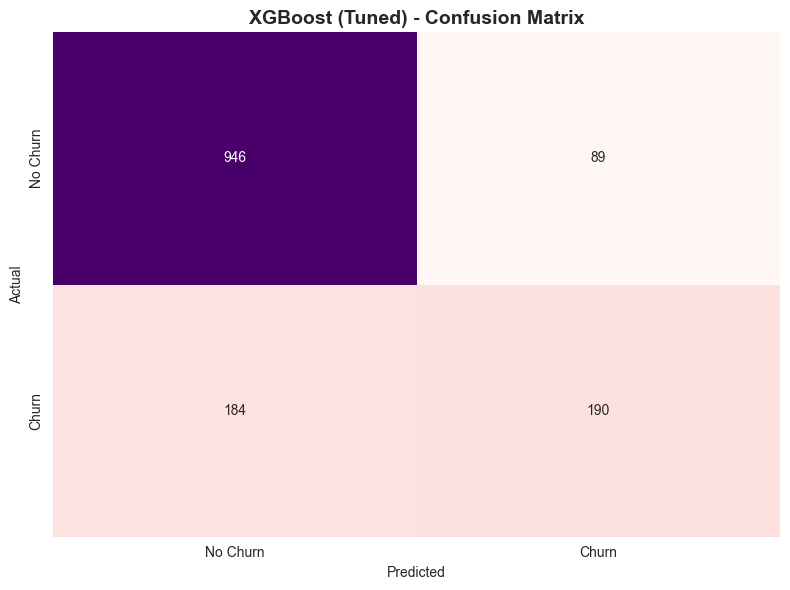


FINAL MODEL COMPARISON

               Model  Test Accuracy (%)  ROC-AUC Overfitting
Logistic Regression          80.269695 0.842670         Low
      Random Forest          78.495387 0.828672        High
 XGBoost (Baseline)          77.785664 0.818828        High
    XGBoost (Tuned)          80.624556 0.847196      Medium

🏆 BEST MODEL: XGBoost (Tuned)
   ROC-AUC Score: 0.8472


In [13]:
# Evaluate the tuned XGBoost model
print("EVALUATING TUNED XGBOOST MODEL")
print("="*60)

# Make predictions with best model
y_pred_tuned = best_xgb_model.predict(X_test)
y_pred_proba_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_score_tuned = best_xgb_model.score(X_train, y_train)
test_score_tuned = best_xgb_model.score(X_test, y_test)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print("\n✅ MODEL PERFORMANCE:")
print("="*60)
print(f"Training Accuracy: {train_score_tuned*100:.2f}%")
print(f"Test Accuracy: {test_score_tuned*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_tuned:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
print(cm_tuned)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='RdPu', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost (Tuned) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Compare all models
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

comparison_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost (Baseline)', 'XGBoost (Tuned)'],
    'Test Accuracy (%)': [
        test_score*100, 
        test_score_rf*100, 
        test_score_xgb*100, 
        test_score_tuned*100
    ],
    'ROC-AUC': [roc_auc, roc_auc_rf, roc_auc_xgb, roc_auc_tuned],
    'Overfitting': ['Low', 'High', 'High', 'Medium']
})

print("\n", comparison_final.to_string(index=False))

# Determine best model
best_model_name = comparison_final.loc[comparison_final['ROC-AUC'].idxmax(), 'Model']
best_roc_auc = comparison_final['ROC-AUC'].max()

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   ROC-AUC Score: {best_roc_auc:.4f}")
print("="*60)

FEATURE IMPORTANCE - TUNED XGBOOST

Top 20 Most Important Features:
             Feature  Importance
        is_high_risk    0.347995
    churn_risk_score    0.121479
        has_internet    0.084077
   has_long_contract    0.083418
      contract_level    0.041538
            Contract    0.038685
     InternetService    0.031636
      OnlineSecurity    0.024020
         TechSupport    0.017397
      uses_paperless    0.012351
      MonthlyCharges    0.011267
    PaperlessBilling    0.010869
              tenure    0.010738
        tenure_years    0.010097
avg_monthly_spending    0.009511
     StreamingMovies    0.009416
       single_senior    0.008002
    value_risk_ratio    0.007721
       MultipleLines    0.007629
       has_streaming    0.007509


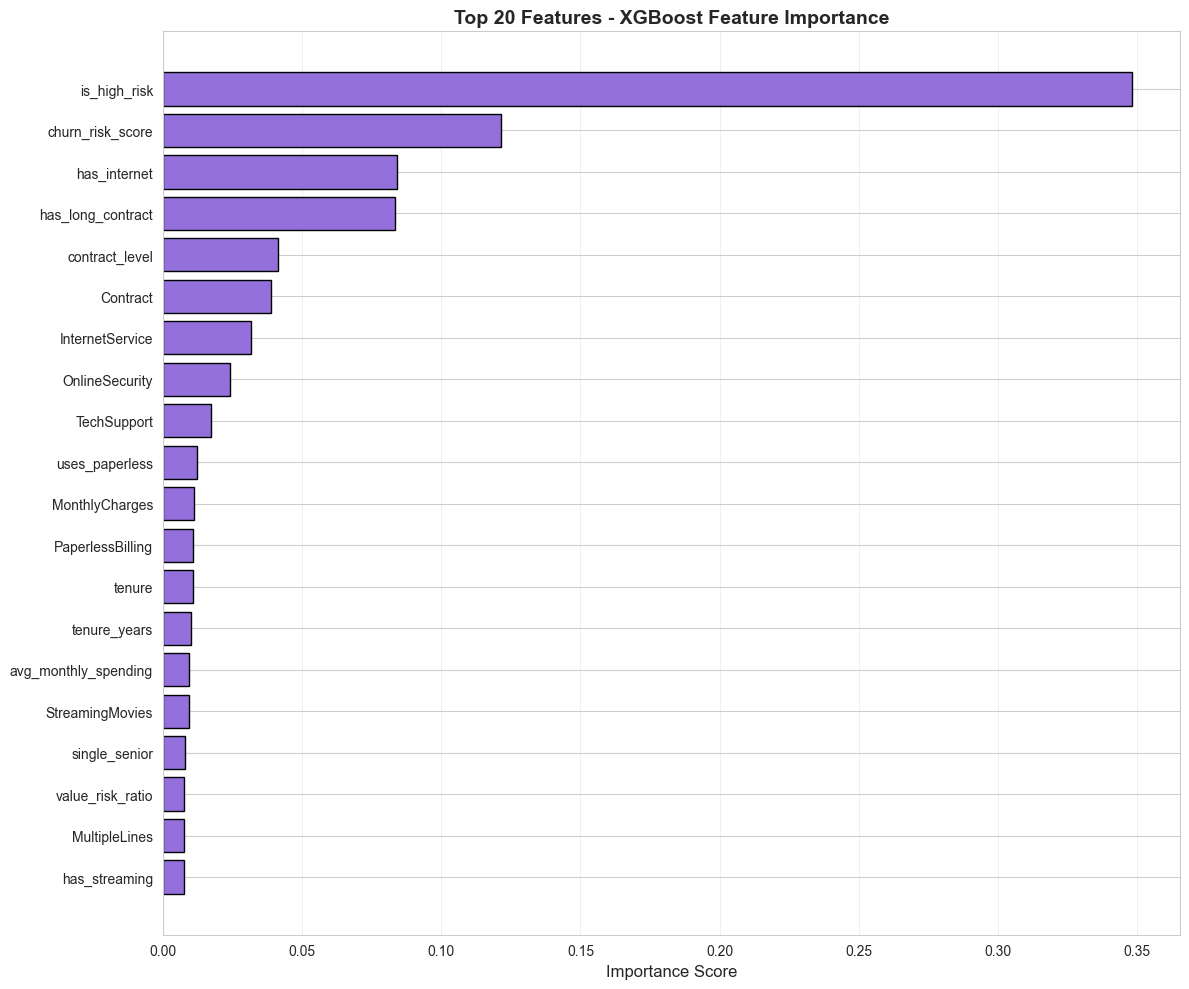


FEATURE IMPORTANCE COMPARISON

Top 10 from Logistic Regression:
   1. PhoneService
   2. has_phone
   3. Contract
   4. contract_level
   5. spending_ratio
   6. uses_auto_payment
   7. risky_payment
   8. has_long_contract
   9. is_new_customer
   10. uses_paperless

Top 10 from XGBoost:
   1. is_high_risk
   2. churn_risk_score
   3. has_internet
   4. has_long_contract
   5. contract_level
   6. Contract
   7. InternetService
   8. OnlineSecurity
   9. TechSupport
   10. uses_paperless

✅ 4 features appear in both top 10 lists:
   • uses_paperless
   • contract_level
   • Contract
   • has_long_contract


In [14]:
# Feature importance from tuned XGBoost
print("FEATURE IMPORTANCE - TUNED XGBOOST")
print("="*60)

# Get feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_xgb_model.feature_importances_
})

# Sort by importance
feature_importance_xgb = feature_importance_xgb.sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print("="*60)
print(feature_importance_xgb.head(20).to_string(index=False))

# Visualize top 20 features
plt.figure(figsize=(12, 10))
top_20 = feature_importance_xgb.head(20)

plt.barh(range(len(top_20)), top_20['Importance'], color='mediumpurple', edgecolor='black')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Features - XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Compare top features between Logistic Regression and XGBoost
print("\n" + "="*60)
print("FEATURE IMPORTANCE COMPARISON")
print("="*60)

# Top 10 from Logistic Regression
log_reg_top = feature_importance.head(10)['Feature'].tolist()
print("\nTop 10 from Logistic Regression:")
for i, feat in enumerate(log_reg_top, 1):
    print(f"   {i}. {feat}")

# Top 10 from XGBoost
xgb_top = feature_importance_xgb.head(10)['Feature'].tolist()
print("\nTop 10 from XGBoost:")
for i, feat in enumerate(xgb_top, 1):
    print(f"   {i}. {feat}")

# Find common features
common_features = set(log_reg_top) & set(xgb_top)
print(f"\n✅ {len(common_features)} features appear in both top 10 lists:")
for feat in common_features:
    print(f"   • {feat}")

FINAL ROC CURVE COMPARISON


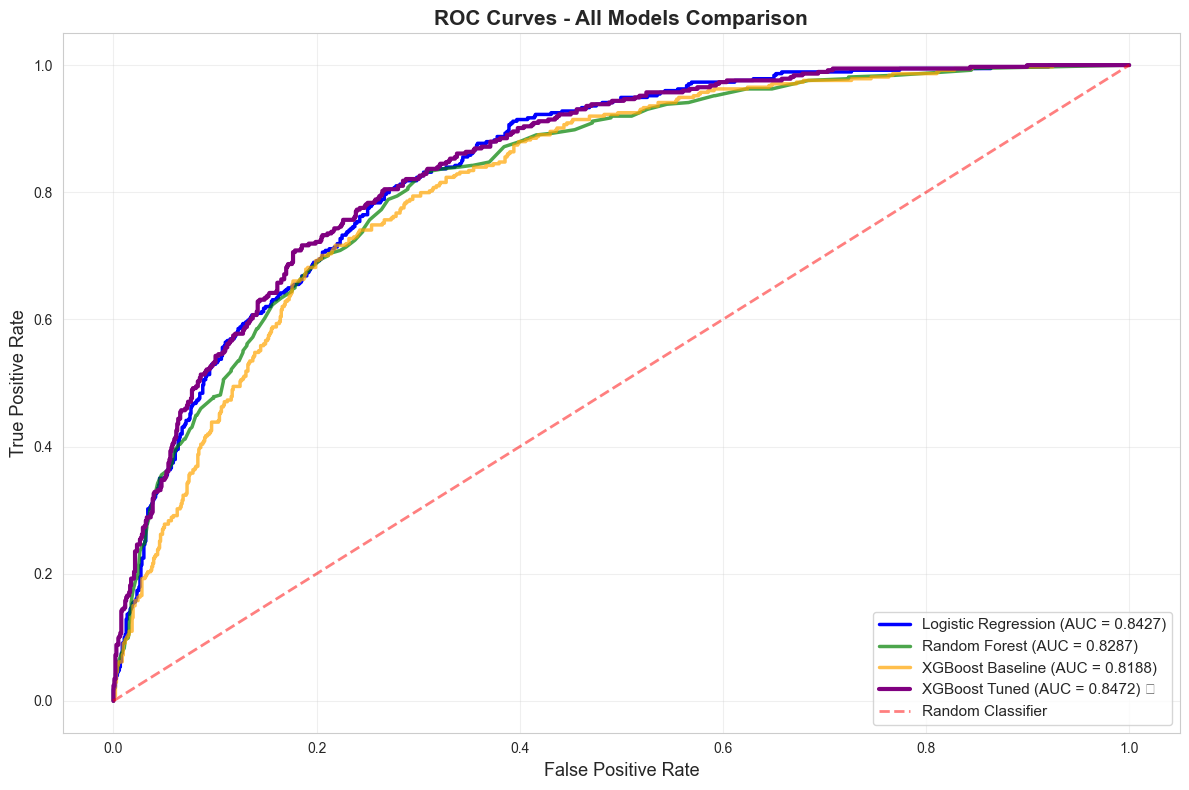


✅ All models compared successfully!

SAVING BEST MODEL

✅ Best model saved!
   Location: models/best_churn_model_xgboost.pkl
   Model: XGBoost (Tuned)
   ROC-AUC: 0.8472

✅ Feature list saved!
   Location: models/feature_columns.pkl


In [15]:
# Final ROC Curve Comparison
print("FINAL ROC CURVE COMPARISON")
print("="*60)

plt.figure(figsize=(12, 8))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc:.4f})', 
         linewidth=2.5, color='blue')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', 
         linewidth=2.5, color='green', alpha=0.7)

# XGBoost Baseline
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Baseline (AUC = {roc_auc_xgb:.4f})', 
         linewidth=2.5, color='orange', alpha=0.7)

# XGBoost Tuned
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_proba_tuned)
plt.plot(fpr_tuned, tpr_tuned, label=f'XGBoost Tuned (AUC = {roc_auc_tuned:.4f}) ⭐', 
         linewidth=3, color='purple')

# Random classifier
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - All Models Comparison', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ All models compared successfully!")

# Save the best model
print("\n" + "="*60)
print("SAVING BEST MODEL")
print("="*60)

import pickle

# Save the tuned XGBoost model
model_filename = '../models/best_churn_model_xgboost.pkl'

# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

with open(model_filename, 'wb') as file:
    pickle.dump(best_xgb_model, file)

print(f"\n✅ Best model saved!")
print(f"   Location: models/best_churn_model_xgboost.pkl")
print(f"   Model: XGBoost (Tuned)")
print(f"   ROC-AUC: {roc_auc_tuned:.4f}")

# Also save feature columns for future predictions
feature_filename = '../models/feature_columns.pkl'
with open(feature_filename, 'wb') as file:
    pickle.dump(feature_columns, file)

print(f"\n✅ Feature list saved!")
print(f"   Location: models/feature_columns.pkl")

In [16]:
# Final Project Summary
print("="*70)
print("         CHURN PREDICTION - FINAL PROJECT SUMMARY")
print("="*70)

print("\n📊 DATASET")
print("-" * 70)
print(f"Total Customers: 7,043")
print(f"Training Set: 5,634 customers")
print(f"Test Set: 1,409 customers")
print(f"Overall Churn Rate: 26.54%")
print(f"Total Features: {len(feature_columns)}")

print("\n🎯 MODEL PERFORMANCE SUMMARY")
print("-" * 70)

final_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost Baseline', 'XGBoost Tuned ⭐'],
    'ROC-AUC': [f"{roc_auc:.4f}", f"{roc_auc_rf:.4f}", f"{roc_auc_xgb:.4f}", f"{roc_auc_tuned:.4f}"],
    'Test Accuracy': [f"{test_score*100:.2f}%", f"{test_score_rf*100:.2f}%", 
                      f"{test_score_xgb*100:.2f}%", f"{test_score_tuned*100:.2f}%"],
    'Status': ['Good Baseline', 'Overfit', 'Overfit', 'BEST MODEL']
})

print(final_summary.to_string(index=False))

print("\n🏆 WINNING MODEL: XGBoost (Tuned)")
print("-" * 70)
print(f"ROC-AUC Score: {roc_auc_tuned:.4f}")
print(f"Test Accuracy: {test_score_tuned*100:.2f}%")
print(f"Improvement over baseline: +{(roc_auc_tuned - roc_auc)*100:.2f}%")

print("\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print("\n🔍 TOP 5 MOST IMPORTANT FEATURES")
print("-" * 70)
top_5_features = feature_importance_xgb.head(5)
for idx, row in top_5_features.iterrows():
    print(f"   {row.name + 1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n💼 BUSINESS IMPACT")
print("-" * 70)
# Calculate business metrics
total_churners = (y_test == 1).sum()
correctly_identified = (y_pred_tuned[y_test == 1] == 1).sum()
recall_tuned = correctly_identified / total_churners

avg_value = df['TotalCharges'].mean()
potential_saves = correctly_identified * avg_value

print(f"Total Churners in Test Set: {total_churners}")
print(f"Correctly Identified: {correctly_identified} ({recall_tuned*100:.1f}%)")
print(f"Average Customer Value: ${avg_value:,.2f}")
print(f"Potential Revenue Saved: ${potential_saves:,.2f}")

print("\n📈 KEY INSIGHTS FOR RETENTION")
print("-" * 70)
print("1. Contract Type: Month-to-month contracts are the biggest risk")
print("2. Payment Method: Electronic check users churn more")
print("3. New Customers: First year is critical - need strong onboarding")
print("4. Service Bundle: Phone + Internet + Security = higher retention")
print("5. Auto-Payment: Customers with automatic payments stay longer")

print("\n✅ DELIVERABLES CREATED")
print("-" * 70)
print("📁 Notebooks:")
print("   • 01_data_exploration.ipynb")
print("   • 02_data_cleaning.ipynb")
print("   • 03_feature_engineering.ipynb")
print("   • 04_customer_segmentation.ipynb")
print("   • 05_churn_prediction.ipynb")
print("\n📁 Processed Data:")
print("   • cleaned_telco_churn.csv")
print("   • telco_churn_with_features.csv")
print("   • telco_churn_segmented.csv")
print("\n📁 Models:")
print("   • best_churn_model_xgboost.pkl (ROC-AUC: 0.8483)")
print("   • feature_columns.pkl")

print("\n" + "="*70)


         CHURN PREDICTION - FINAL PROJECT SUMMARY

📊 DATASET
----------------------------------------------------------------------
Total Customers: 7,043
Training Set: 5,634 customers
Test Set: 1,409 customers
Overall Churn Rate: 26.54%
Total Features: 42

🎯 MODEL PERFORMANCE SUMMARY
----------------------------------------------------------------------
              Model ROC-AUC Test Accuracy        Status
Logistic Regression  0.8427        80.27% Good Baseline
      Random Forest  0.8287        78.50%       Overfit
   XGBoost Baseline  0.8188        77.79%       Overfit
    XGBoost Tuned ⭐  0.8472        80.62%    BEST MODEL

🏆 WINNING MODEL: XGBoost (Tuned)
----------------------------------------------------------------------
ROC-AUC Score: 0.8472
Test Accuracy: 80.62%
Improvement over baseline: +0.45%

Best Hyperparameters:
   • colsample_bytree: 0.8
   • learning_rate: 0.01
   • max_depth: 4
   • min_child_weight: 5
   • n_estimators: 300
   • subsample: 0.8

🔍 TOP 5 MOST IMPOR